>>> Veri seti okunuyor: C:\Users\w11\dergi2\processed_data\final\12_final.xlsx
>>> Korelasyon için sütunlar seçiliyor...
>>> Korelasyon hesaplanıyor...

Table 4. Correlation coefficients
     Parameters     Value
        G_Solar  0.999309
        A_Solar  0.999309
        C_Solar  0.817476
    Temperature  0.247469
           CEEI  0.223340
     Population  0.212019
      C_Biomass  0.173144
     Wind_Speed  0.130096
      G_Biomass  0.075595
      A_Biomass  0.075595
Solar_Radiation  0.051312
   C_Hydropower  0.049988
         A_Wind  0.011130
         G_Wind  0.011130
         C_Wind -0.009122
   A_Hydropower -0.038700
   G_Hydropower -0.038700
       Rainfall -0.271964
----------------------------------------
>>> Grafikler çizdiriliyor (Lütfen açılan pencereleri kontrol edin)...


C:\Users\W11\AppData\Local\Temp\ipykernel_14004\1900221543.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=t_emission_corr.values, y=t_emission_corr.index, palette='viridis')


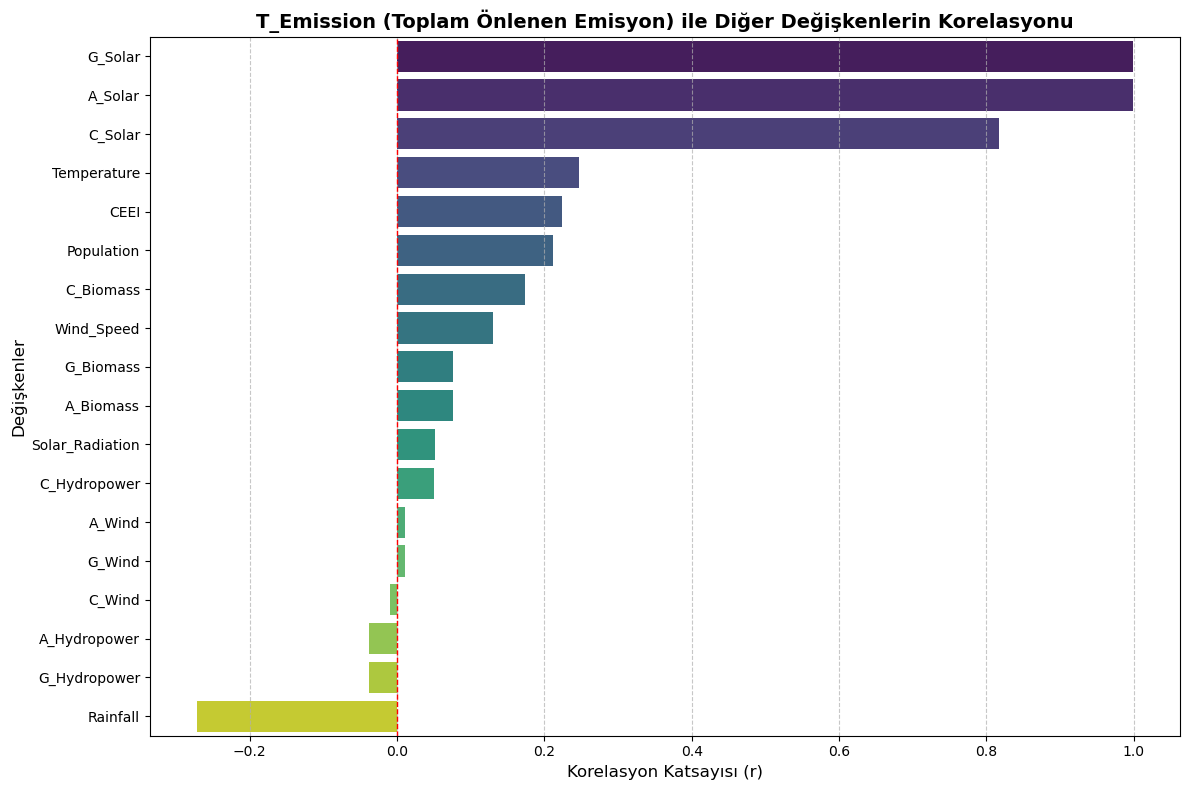

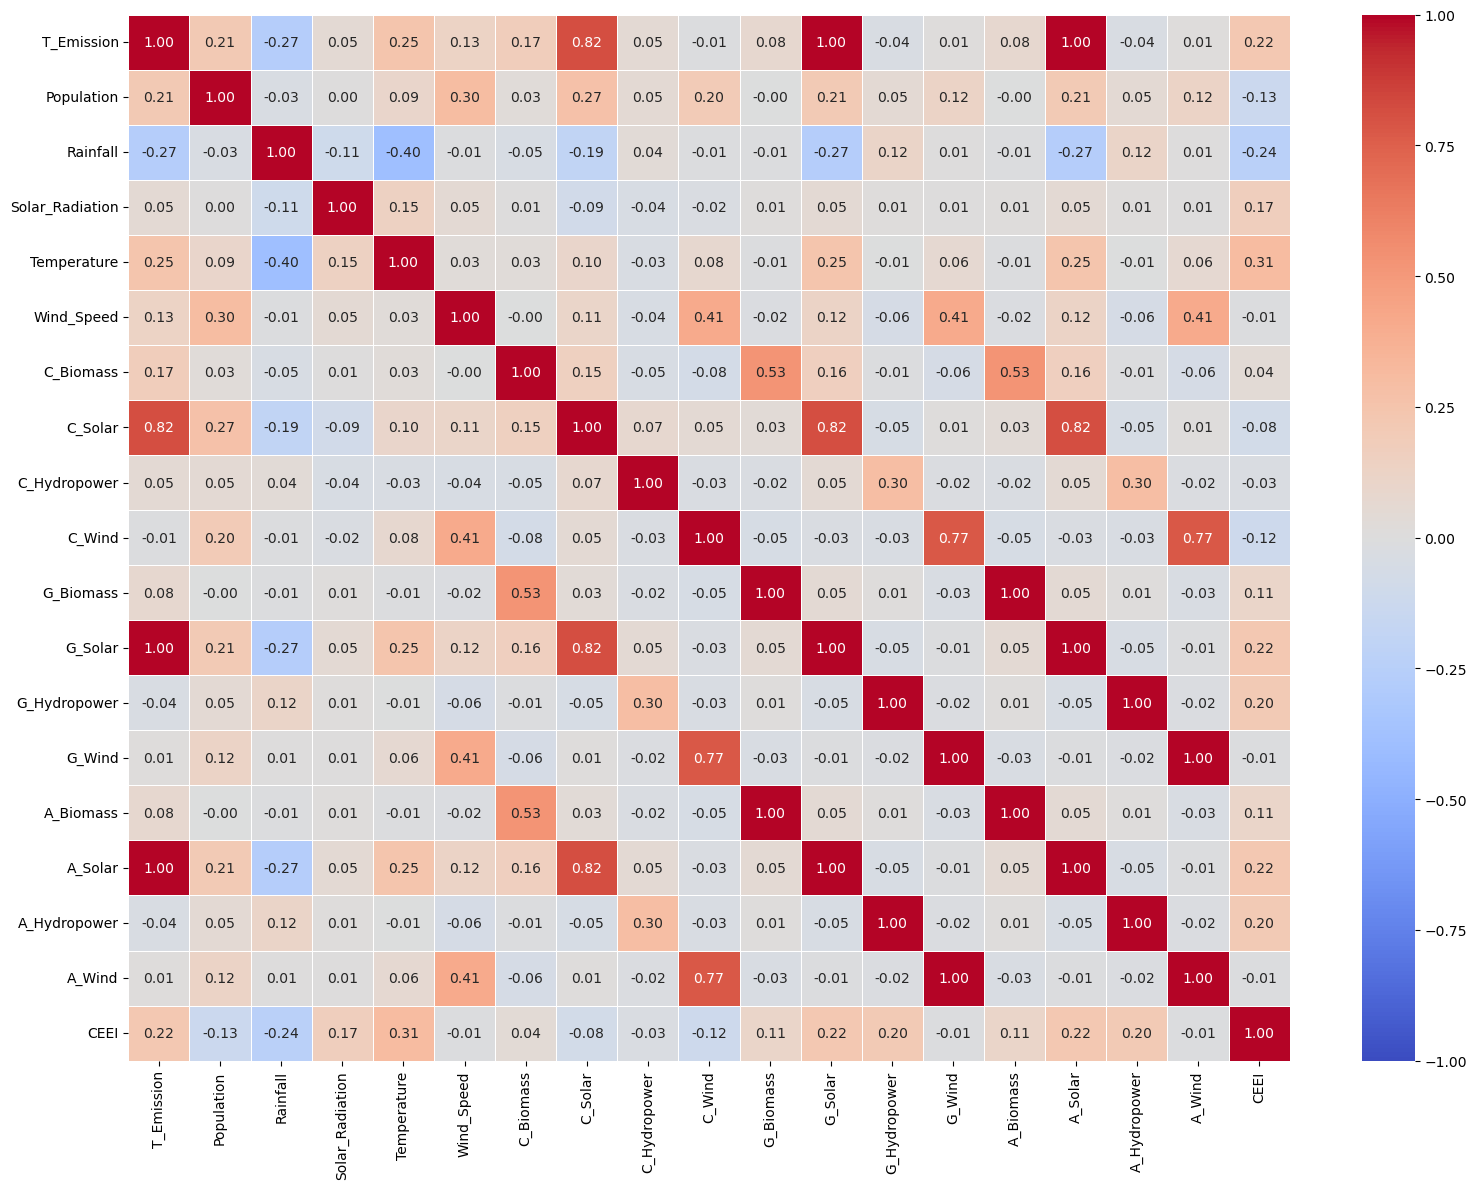

>>> İşlem tamamlandı.


In [3]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# 1. DOSYA YOLU VE VERİYİ OKUMA
# =====================================================
base_dir = r"C:\Users\w11\dergi2"
input_file = os.path.join(base_dir, "processed_data", "final", "12_final.xlsx")

print(f">>> Veri seti okunuyor: {input_file}")
df = pd.read_excel(input_file)

# =====================================================
# 2. KORELASYONA GİRECEK SÜTUNLARI BELİRLEME
# =====================================================
print(">>> Korelasyon için sütunlar seçiliyor...")

# DİKKAT: Korelasyona girmesini İSTEMEDİĞİNİZ sütunların o satırını silebilir
# veya başına '#' işareti koyarak (yorum satırı yaparak) iptal edebilirsiniz.
# T_Emission'ı hedef değişken olduğu için hep en üstte bırakmanız tavsiye edilir.
secilen_sutunlar = [
    'T_Emission',
#    'Year',
#    'Month',
    'Population',
    'Rainfall',
    'Solar_Radiation',
    'Temperature',
    'Wind_Speed',
    'C_Biomass',
    'C_Solar',
    'C_Hydropower',
    'C_Wind',
    'G_Biomass',
    'G_Solar',
    'G_Hydropower',
    'G_Wind',
    'A_Biomass',
    'A_Solar',
    'A_Hydropower',
    'A_Wind',
    'CEEI'
]

# Sadece veri setinde gerçekten var olan ve yukarıdaki listede aktif olan sütunları al
gecerli_sutunlar = [col for col in secilen_sutunlar if col in df.columns]

# Veri setini sadece seçilen sütunlarla sınırla
df_korelasyon = df[gecerli_sutunlar]

# Sadece sayısal verileri tut (Olası metin hatalarını önlemek için)
df_numeric = df_korelasyon.select_dtypes(include=['number'])

# =====================================================
# 3. KORELASYON ANALİZİ VE TABLO YAZDIRMA
# =====================================================
print(">>> Korelasyon hesaplanıyor...")

# Korelasyon matrisini oluştur
corr_matrix = df_numeric.corr()

# T_Emission ile olan ilişkileri ayır ve büyükten küçüğe sırala
t_emission_corr = corr_matrix['T_Emission'].drop('T_Emission').sort_values(ascending=False)

# Tabloyu Konsola Yazdır
print("\nTable 4. Correlation coefficients")
table_df = pd.DataFrame({'Parameters': t_emission_corr.index, 'Value': t_emission_corr.values})
pd.options.display.float_format = '{:.6f}'.format
print(table_df.to_string(index=False))
print("-" * 40)

# =====================================================
# 4. GÖRSELLEŞTİRME: T_Emission Odaklı Çubuk Grafik
# =====================================================
print(">>> Grafikler çizdiriliyor (Lütfen açılan pencereleri kontrol edin)...")

plt.figure(figsize=(12, 8))
sns.barplot(x=t_emission_corr.values, y=t_emission_corr.index, palette='viridis')

# Grafik ayarları
plt.title('T_Emission (Toplam Önlenen Emisyon) ile Diğer Değişkenlerin Korelasyonu', fontsize=14, fontweight='bold')
plt.xlabel('Korelasyon Katsayısı (r)', fontsize=12)
plt.ylabel('Değişkenler', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Grafiği göster
plt.show()

# =====================================================
# 5. GÖRSELLEŞTİRME: Tüm Değişkenler İçin Isı Haritası
# =====================================================
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)

# Grafik ayarları
# plt.title('Tüm Değişkenlerin Korelasyon Matrisi', fontsize=16, fontweight='bold')
plt.tight_layout()

# Grafiği göster
plt.show()

print(">>> İşlem tamamlandı.")

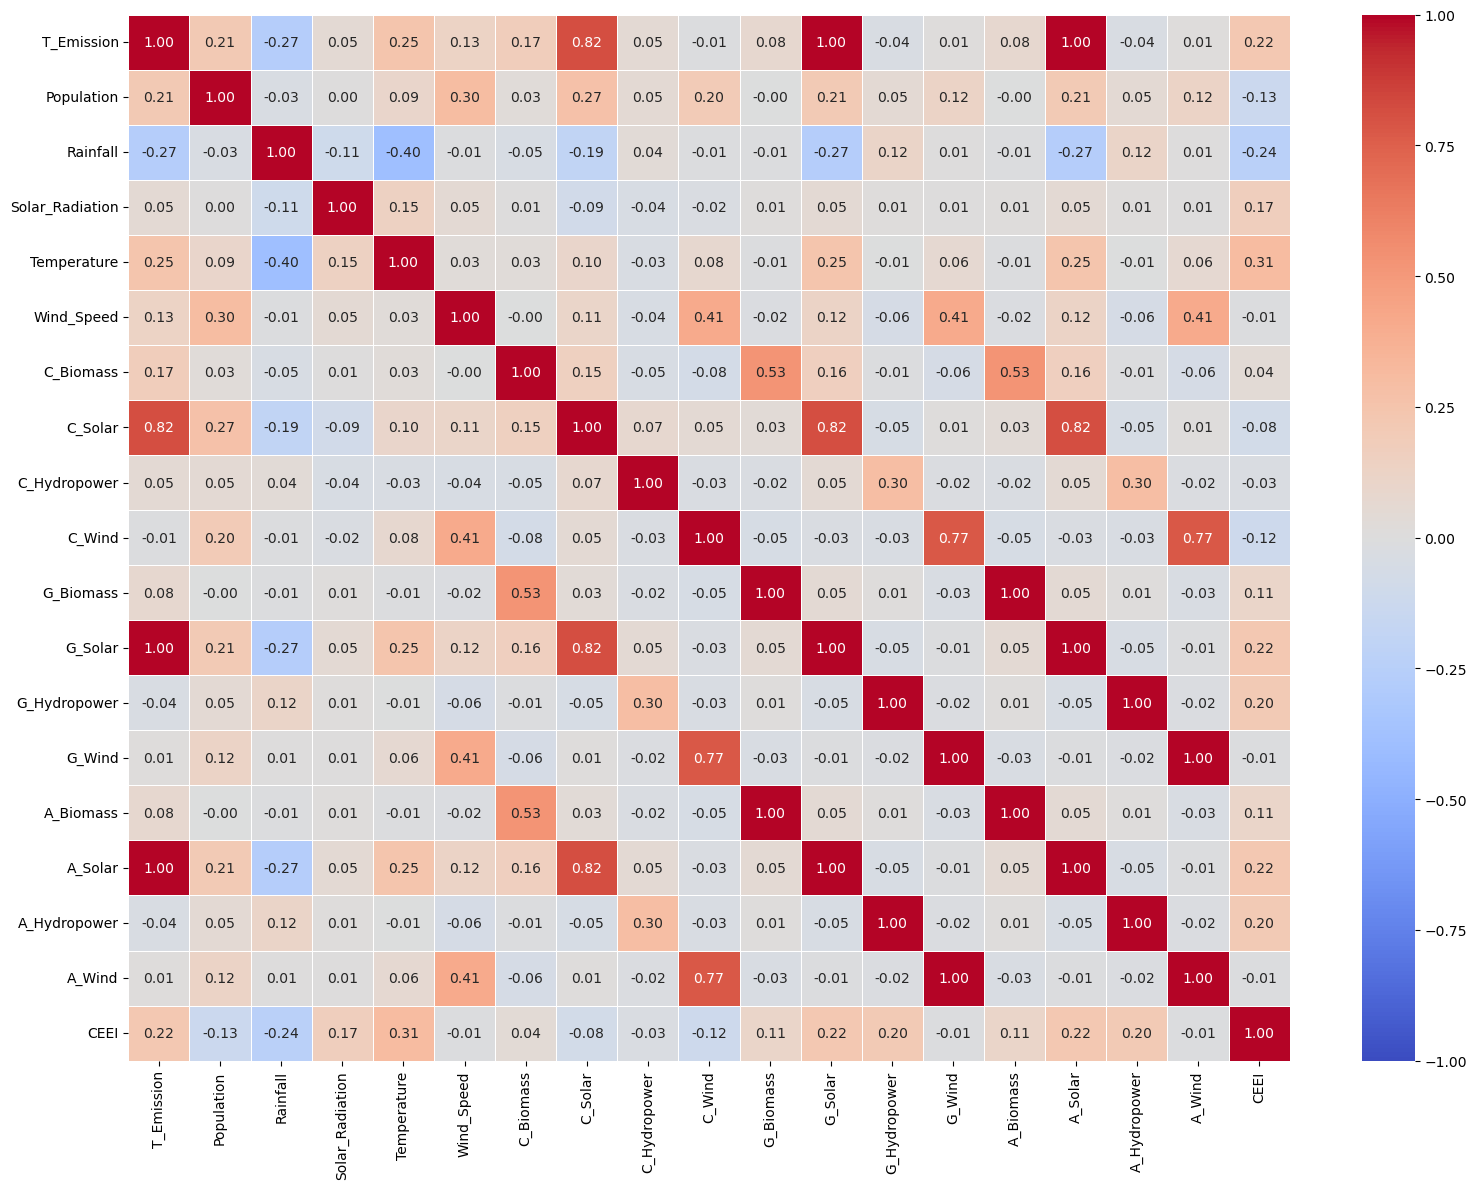

In [4]:
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)

# Grafik ayarları
#plt.title('Tüm Değişkenlerin Korelasyon Matrisi', fontsize=16, fontweight='bold')
plt.tight_layout()

# Grafiği göster
plt.show()


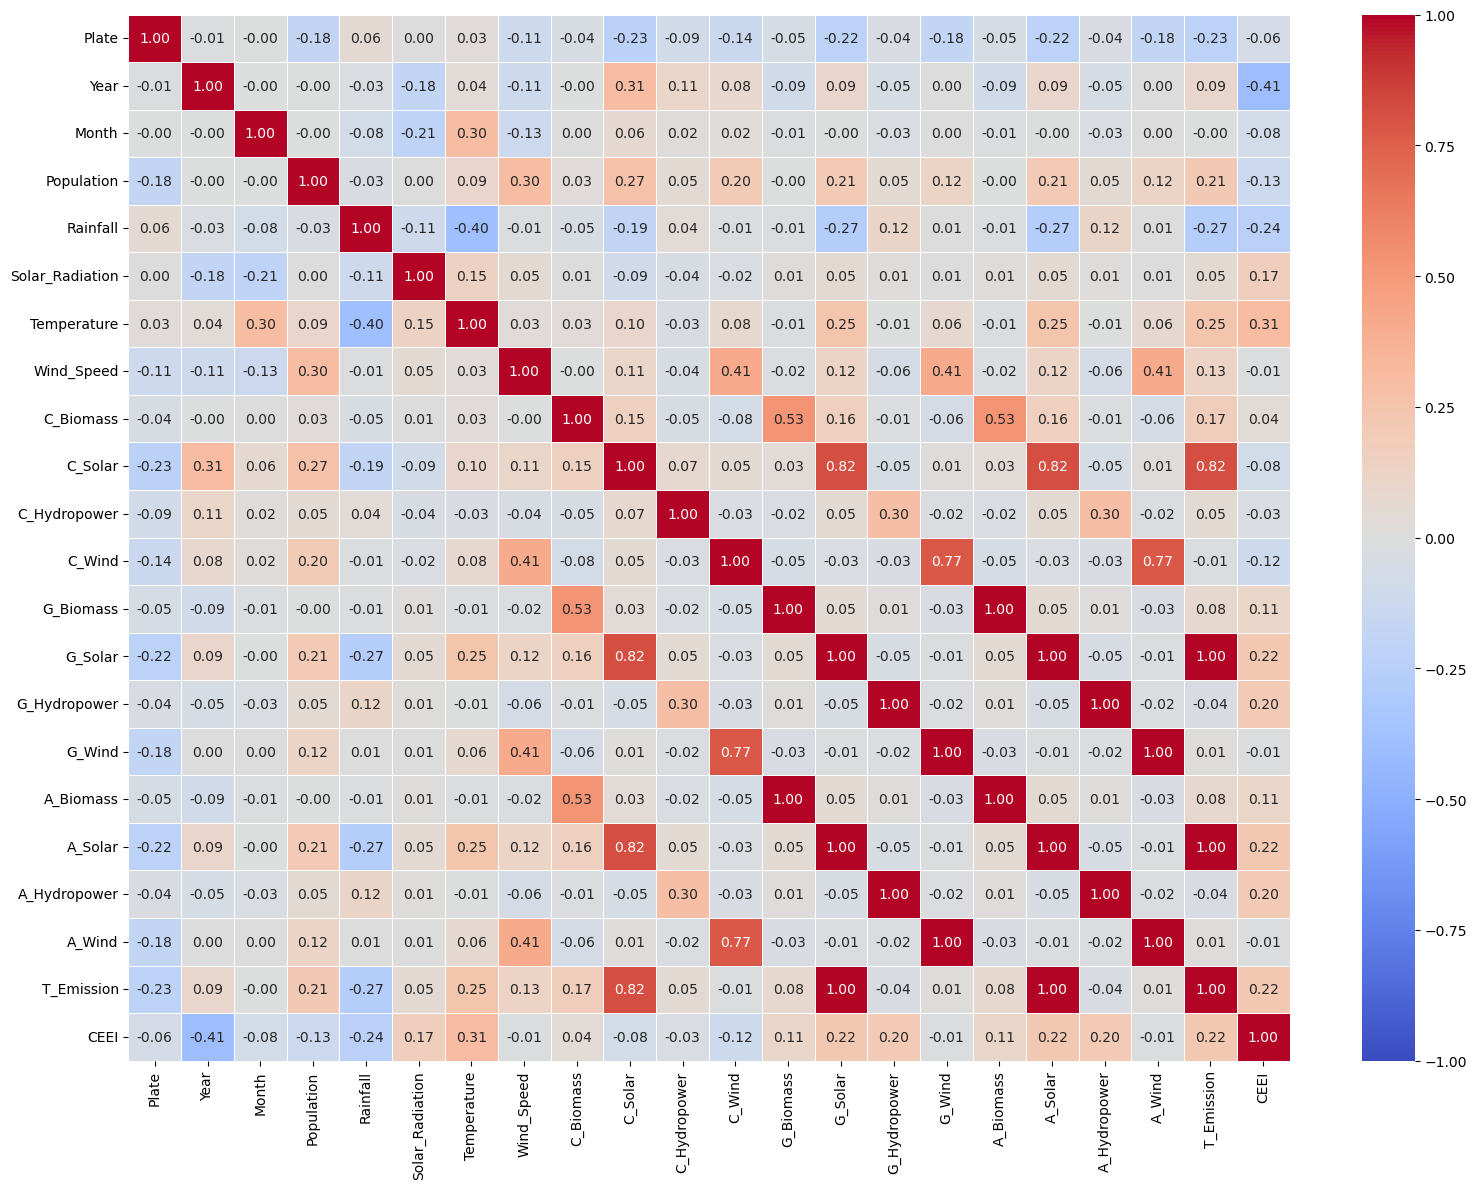

Grafik 'korelasyon_matrisi.png' olarak başarıyla kaydedildi.


In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Veri setinizi yükleyin (dosya yolunun doğru olduğundan emin olun)
df = pd.read_excel('C:/Users/W11/dergi2/processed_data/final/12_final.xlsx')

# 2. Korelasyon matrisini hesaplayın
corr_matrix = df.corr()

# 3. Grafik ayarları
plt.figure(figsize=(16, 12))

# 4. Heatmap oluşturma
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)

# 5. Başlık ve düzenleme
#plt.title('Tüm Değişkenlerin Korelasyon Matrisi', fontsize=16, fontweight='bold')
plt.tight_layout()

# 6. Grafiği PNG olarak kaydetme
plt.savefig('C:/Users/W11/dergi2/results/figures/korelasyon_matrisi.png', dpi=300)

# Grafiği ekranda göster
plt.show()

print("Grafik 'korelasyon_matrisi.png' olarak başarıyla kaydedildi.")